# Notebook 02 — glenglat ML analysis: clustering and decision tree regression

Explores data-driven approaches to ΔT_firn prediction beyond linear regression.
Companion to `01_glenglat_T15m_regression.ipynb`.

**Prerequisite**: run notebook 01 through the export cell to generate
`../data/glenglat_profiles_derived.csv`.

**Questions addressed**:
1. How many natural climate clusters does the data support — 2, 3, or more?
   Do data-driven clusters align with the existing 3-regime classification?
2. Can a decision tree beat the linear T_amplitude regression (r²=0.479)?
   What feature drives the first split?
3. What is the non-parametric prediction ceiling (KNN)?

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from scipy import stats as _stats

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

DATA_CSV = '../data/glenglat_profiles_derived.csv'

REGIME_ORDER  = ['Polar / High-Arctic', 'Temperate / Maritime', 'Sub-Continental']
REGIME_COLORS = {
    'Polar / High-Arctic':  '#4393c3',
    'Temperate / Maritime': '#4dac26',
    'Sub-Continental':      '#d01c8b',
}
# Cluster palette — tab10 colormap supports up to 10 clusters
CLUSTER_COLORS = [plt.cm.tab10(i / 10) for i in range(10)]

In [9]:
profiles = pd.read_csv(DATA_CSV)
print(f'Loaded {len(profiles)} profiles from {DATA_CSV}')
print(f'Columns: {list(profiles.columns)}')
print()
print('Regime distribution:')
print(profiles['regime'].value_counts().to_string())

Loaded 363 profiles from ../data/glenglat_profiles_derived.csv
Columns: ['borehole_id', 'profile_id', 'glacier_name', 'latitude', 'longitude', 'elevation', 'mass_balance_area', 'regime', 'glogem_region', 'T_maat', 'profile_date_min', 'T_shallow_depth', 'T_shallow', 'dT_firn', 'PDD', 'NDD', 'NDD_ratio', 'T_amplitude']

Regime distribution:
regime
Temperate / Maritime    143
Sub-Continental         114
Polar / High-Arctic     106


In [10]:
# Same filter as notebook 01 cell 33: ablation zone + near-PMP excluded
PMP_THRESH = -0.5

sub = profiles.dropna(subset=['T_amplitude', 'dT_firn']).copy()
profiles_filt = sub[
    (sub['T_shallow'] <= PMP_THRESH) &
    (sub['mass_balance_area'] != 'ablation')
].copy()

n_all, n_filt = len(sub), len(profiles_filt)
print(f'Profiles with T_amplitude and dT_firn: {n_all}')
print(f'After ablation + near-PMP filter:       {n_filt}  (removed {n_all - n_filt})')
print()
print('Filtered regime distribution:')
print(profiles_filt['regime'].value_counts().to_string())
print()
print('Feature summary:')
print(profiles_filt[['T_amplitude', 'T_maat', 'PDD', 'elevation', 'latitude', 'dT_firn']]
      .describe().round(1).to_string())

Profiles with T_amplitude and dT_firn: 363
After ablation + near-PMP filter:       208  (removed 155)

Filtered regime distribution:
regime
Temperate / Maritime    109
Polar / High-Arctic      53
Sub-Continental          46

Feature summary:
       T_amplitude  T_maat    PDD  elevation  latitude  dT_firn
count        208.0   208.0  208.0      208.0     208.0    208.0
mean          22.5   -11.8  100.0     3031.0      50.2      5.7
std            5.3     4.9  112.8     1438.7      25.4      3.6
min            7.6   -23.8    0.0      300.0     -66.0     -1.6
25%           19.7   -14.1    0.0     1636.5      43.0      3.3
50%           20.1    -9.0   56.8     3530.0      45.9      4.9
75%           25.5    -7.6  171.7     4200.0      75.9      8.3
max           36.0    -5.7  406.9     6340.0      80.8     14.4


---
## 1. K-means clustering: how many natural climate regimes?

Cluster on: `T_amplitude`, `T_maat`, `PDD`, `elevation`, `latitude`.
All standardised to zero mean / unit variance before clustering.
Optimal k determined by silhouette score (higher = more compact, well-separated clusters).

Comparing against the 3-regime classification tests whether the regime labels
reflect actual structure in the climate feature space.

In [11]:
CLUST_FEATURES = ['T_amplitude', 'T_maat', 'PDD', 'elevation', 'latitude']
df_clust = profiles_filt[CLUST_FEATURES].dropna()
X_clust  = df_clust.values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# Carry dT_firn and regime alongside for interpretation
clust_meta = profiles_filt.loc[df_clust.index, ['dT_firn', 'regime']].copy()

print(f'Clustering on {len(df_clust)} samples × {len(CLUST_FEATURES)} features')
print(f'Features: {CLUST_FEATURES}')

Clustering on 208 samples × 5 features
Features: ['T_amplitude', 'T_maat', 'PDD', 'elevation', 'latitude']


Silhouette scores:
  k=2: 0.538
  k=3: 0.548
  k=4: 0.586
  k=5: 0.664
  k=6: 0.719
  k=7: 0.723 ← best


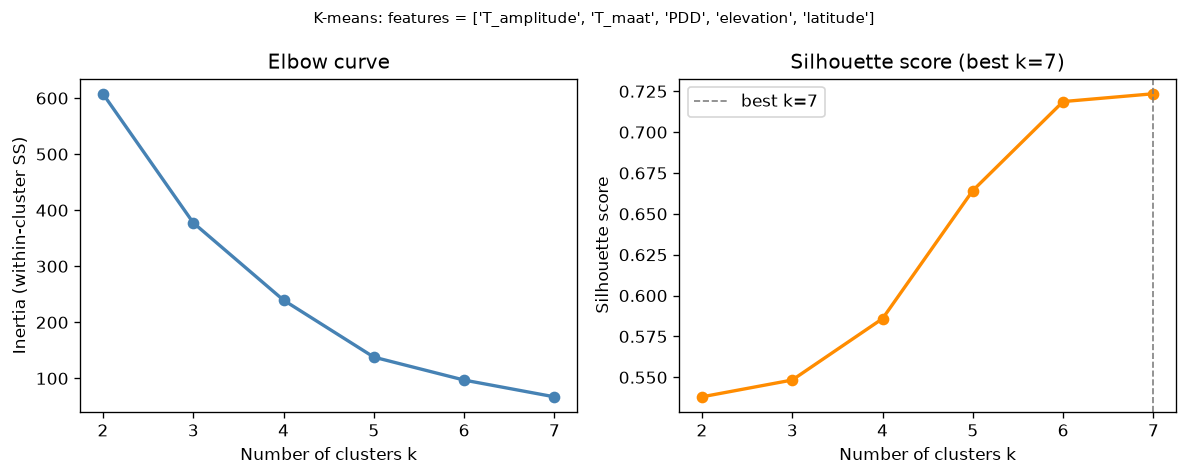

Saved: figures/fig_10_kmeans_elbow.pdf


In [12]:
Ks = range(2, 8)
inertias, sil_scores = [], []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = list(Ks)[int(np.argmax(sil_scores))]
print('Silhouette scores:')
for k, s in zip(Ks, sil_scores):
    marker = ' ← best' if k == best_k else ''
    print(f'  k={k}: {s:.3f}{marker}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(list(Ks), inertias, 'o-', color='steelblue', lw=2)
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia (within-cluster SS)')
ax1.set_title('Elbow curve')
ax1.set_xticks(list(Ks))

ax2.plot(list(Ks), sil_scores, 'o-', color='darkorange', lw=2)
ax2.axvline(best_k, ls='--', color='grey', lw=1, label=f'best k={best_k}')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette score')
ax2.set_title(f'Silhouette score (best k={best_k})')
ax2.set_xticks(list(Ks))
ax2.legend()

plt.suptitle(f'K-means: features = {CLUST_FEATURES}', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/fig_10_kmeans_elbow.pdf', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: figures/fig_10_kmeans_elbow.pdf')

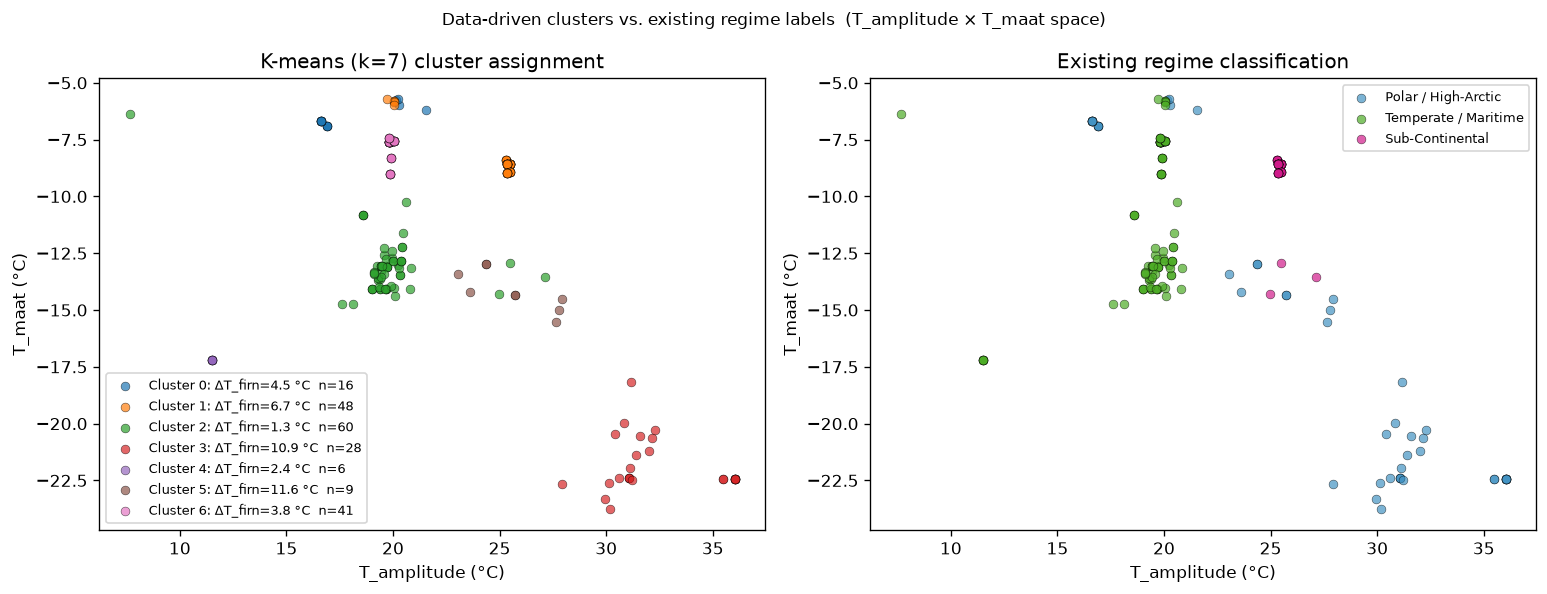

Saved: figures/fig_11_kmeans_clusters.pdf

ΔT_firn statistics per k-means cluster (k=7):
  Cluster 0 (n= 16): median=4.47  IQR=[4.37, 4.63]
  Cluster 1 (n= 48): median=6.66  IQR=[6.65, 8.27]
  Cluster 2 (n= 60): median=1.32  IQR=[0.60, 4.45]
  Cluster 3 (n= 28): median=10.92  IQR=[8.98, 11.02]
  Cluster 4 (n=  6): median=2.44  IQR=[2.42, 2.47]
  Cluster 5 (n=  9): median=11.62  IQR=[10.18, 12.47]
  Cluster 6 (n= 41): median=3.81  IQR=[3.44, 4.05]

Regime distribution per cluster:
regime   Polar / High-Arctic  Sub-Continental  Temperate / Maritime
cluster                                                            
0                         16                0                     0
1                          0               43                     5
2                          0                3                    57
3                         28                0                     0
4                          0                0                     6
5                          9           

In [13]:
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_scaled)

df_clust_plot = df_clust.copy()
df_clust_plot['cluster'] = cluster_labels
df_clust_plot['dT_firn'] = clust_meta['dT_firn'].values
df_clust_plot['regime']  = clust_meta['regime'].values

# Two-panel: (a) k-means coloring, (b) regime coloring
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for k in range(best_k):
    mask    = df_clust_plot['cluster'] == k
    dT_med  = df_clust_plot.loc[mask, 'dT_firn'].median()
    ax1.scatter(df_clust_plot.loc[mask, 'T_amplitude'],
                df_clust_plot.loc[mask, 'T_maat'],
                color=CLUSTER_COLORS[k], alpha=0.7, edgecolors='k',
                linewidths=0.3, s=28,
                label=f'Cluster {k}: ΔT_firn={dT_med:.1f} °C  n={mask.sum()}')

ax1.set_xlabel('T_amplitude (°C)')
ax1.set_ylabel('T_maat (°C)')
ax1.set_title(f'K-means (k={best_k}) cluster assignment')
ax1.legend(fontsize=8)

for regime in REGIME_ORDER:
    mask = df_clust_plot['regime'] == regime
    ax2.scatter(df_clust_plot.loc[mask, 'T_amplitude'],
                df_clust_plot.loc[mask, 'T_maat'],
                color=REGIME_COLORS.get(regime, 'grey'), alpha=0.7,
                edgecolors='k', linewidths=0.3, s=28, label=regime)

ax2.set_xlabel('T_amplitude (°C)')
ax2.set_ylabel('T_maat (°C)')
ax2.set_title('Existing regime classification')
ax2.legend(fontsize=8)

plt.suptitle('Data-driven clusters vs. existing regime labels  (T_amplitude × T_maat space)',
             fontsize=10)
plt.tight_layout()
plt.savefig('../figures/fig_11_kmeans_clusters.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_11_kmeans_clusters.pdf')

# ΔT_firn per cluster
print(f'\nΔT_firn statistics per k-means cluster (k={best_k}):')
for k in range(best_k):
    mask = df_clust_plot['cluster'] == k
    vals = df_clust_plot.loc[mask, 'dT_firn']
    print(f'  Cluster {k} (n={mask.sum():3d}): '
          f'median={vals.median():.2f}  '
          f'IQR=[{vals.quantile(0.25):.2f}, {vals.quantile(0.75):.2f}]')

print(f'\nRegime distribution per cluster:')
print(pd.crosstab(df_clust_plot['cluster'], df_clust_plot['regime']))

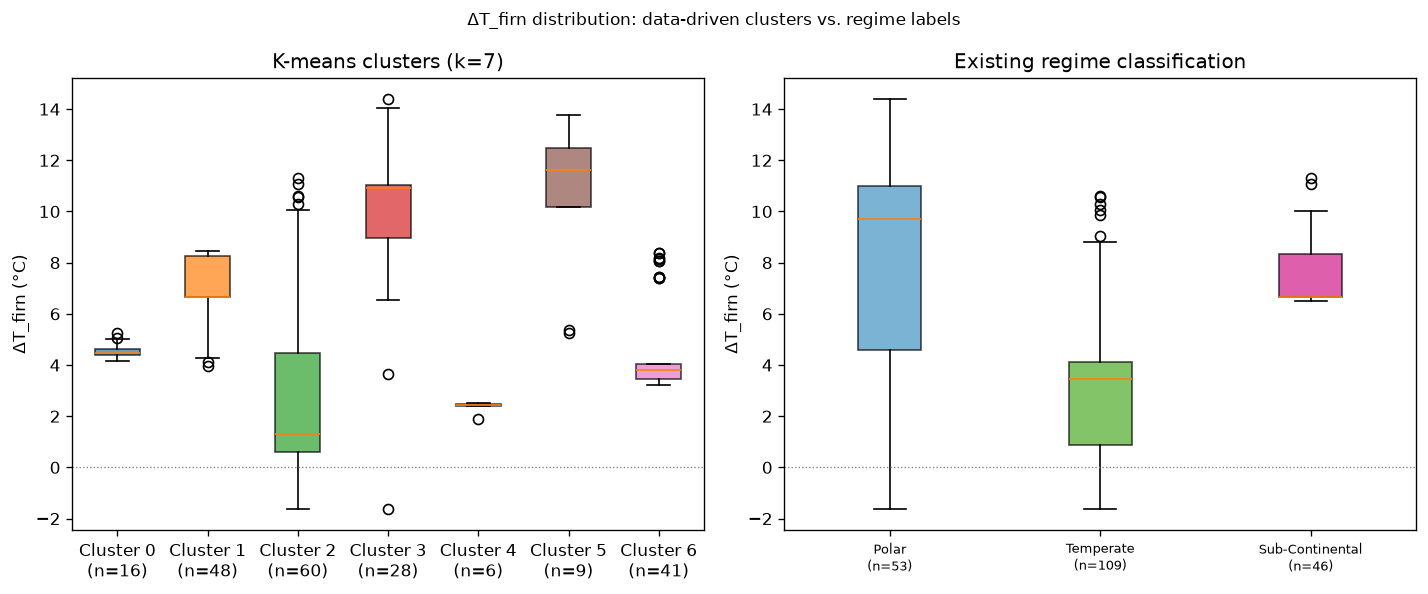

Saved: figures/fig_12_cluster_dT_boxplot.pdf


In [14]:
# Boxplot: ΔT_firn per cluster vs per regime — side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# K-means clusters
cluster_data = [df_clust_plot[df_clust_plot['cluster'] == k]['dT_firn'].dropna()
                for k in range(best_k)]
bp1 = ax1.boxplot(cluster_data, patch_artist=True, notch=False)
for patch, color in zip(bp1['boxes'], [CLUSTER_COLORS[k] for k in range(best_k)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_xticklabels([f'Cluster {k}\n(n={len(d)})' for k, d in enumerate(cluster_data)])
ax1.set_ylabel('ΔT_firn (°C)')
ax1.set_title(f'K-means clusters (k={best_k})')
ax1.axhline(0, color='grey', ls=':', lw=0.8)

# Regime labels
regime_data = [profiles_filt[profiles_filt['regime'] == r]['dT_firn'].dropna()
               for r in REGIME_ORDER]
bp2 = ax2.boxplot(regime_data, patch_artist=True, notch=False)
for patch, r in zip(bp2['boxes'], REGIME_ORDER):
    patch.set_facecolor(REGIME_COLORS[r])
    patch.set_alpha(0.7)
ax2.set_xticklabels([f'{r.split(" / ")[0]}\n(n={len(d)})'
                     for r, d in zip(REGIME_ORDER, regime_data)], fontsize=8)
ax2.set_ylabel('ΔT_firn (°C)')
ax2.set_title('Existing regime classification')
ax2.axhline(0, color='grey', ls=':', lw=0.8)

plt.suptitle('ΔT_firn distribution: data-driven clusters vs. regime labels', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/fig_12_cluster_dT_boxplot.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_12_cluster_dT_boxplot.pdf')

---
## 2. Decision tree regression (CART)

A regression tree recursively splits the feature space to minimise the residual sum
of squares at each step. Key advantages for this problem:
- Naturally captures the step-function structure (Maritime vs Non-Maritime) that a
  linear model cannot
- The first split directly identifies the most informative feature and threshold
- Leaf-node predictions are simple IF rules, directly implementable in GloGEM IDL

**5-fold cross-validation** gives the honest out-of-sample r² (avoids overfitting
artefacts from training-set evaluation). Baseline: T_amplitude linear regression r²≈0.479.

In [15]:
DT_FEATURES = ['T_amplitude', 'T_maat', 'PDD', 'elevation', 'latitude']
df_dt = profiles_filt[DT_FEATURES + ['dT_firn']].dropna()
X     = df_dt[DT_FEATURES].values
y     = df_dt['dT_firn'].values

# Linear baseline (T_amplitude only, 5-fold CV)
X_lin   = df_dt[['T_amplitude']].values
lin_cv  = cross_val_score(LinearRegression(), X_lin, y, cv=5, scoring='r2')
print(f'Linear (T_amplitude only)  CV r² = {lin_cv.mean():.3f} ± {lin_cv.std():.3f}  n={len(y)}')
print()

# Decision tree at depths 1-3 and unlimited
print('Decision tree 5-fold CV r²:')
dt_cv_results = {}
for depth in [1, 2, 3, None]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    cv = cross_val_score(dt, X, y, cv=5, scoring='r2')
    dt_cv_results[depth] = cv.mean()
    print(f'  depth={str(depth):4s}: CV r² = {cv.mean():.3f} ± {cv.std():.3f}')

best_depth = max((d for d in dt_cv_results if d is not None),
                 key=lambda d: dt_cv_results[d])
print(f'\nBest depth by CV r²: {best_depth}')

Linear (T_amplitude only)  CV r² = 0.332 ± 0.040  n=208

Decision tree 5-fold CV r²:
  depth=1   : CV r² = 0.304 ± 0.257
  depth=2   : CV r² = 0.104 ± 0.797
  depth=3   : CV r² = 0.589 ± 0.117
  depth=None: CV r² = 0.591 ± 0.237

Best depth by CV r²: 3


Training r² (depth=2): 0.707

Feature importances (RSS reduction):
  T_amplitude    : 0.710
  elevation      : 0.290
  T_maat         : 0.000
  PDD            : 0.000
  latitude       : 0.000


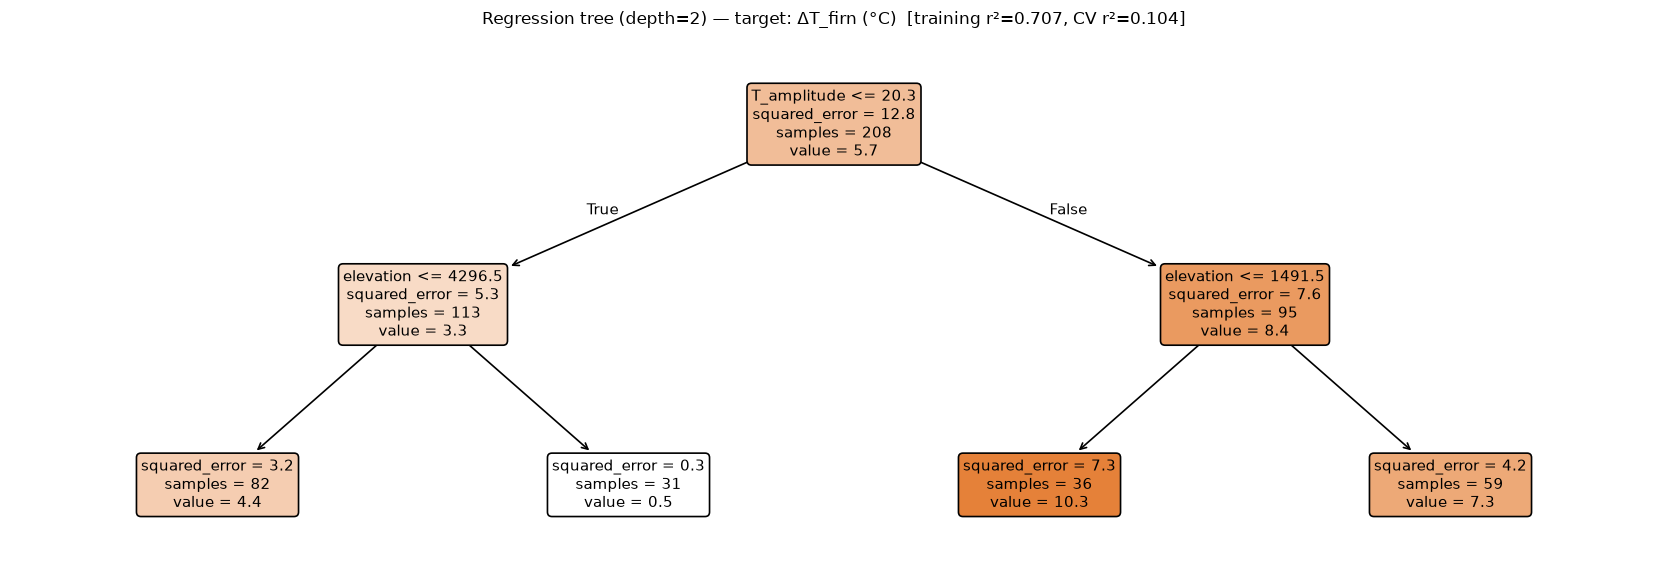

Saved: figures/fig_09_decision_tree.pdf

Leaf node ΔT_firn predictions (n leaves = 4):
  0.54 °C  (n=31 training samples)
  4.40 °C  (n=82 training samples)
  7.26 °C  (n=59 training samples)
  10.34 °C  (n=36 training samples)


In [ ]:
# Fit and visualize the best tree
PLOT_DEPTH = 2  # override if CV suggests different depth

dt_final = DecisionTreeRegressor(max_depth=PLOT_DEPTH, random_state=42)
dt_final.fit(X, y)
print(f'Training r² (depth={PLOT_DEPTH}): {dt_final.score(X, y):.3f}')

# Feature importances
fi = pd.Series(dt_final.feature_importances_, index=DT_FEATURES).sort_values(ascending=False)
print('\nFeature importances (RSS reduction):')
for feat, imp in fi.items():
    print(f'  {feat:<15s}: {imp:.3f}')

# Plot tree
fig, ax = plt.subplots(figsize=(14, 5))
plot_tree(dt_final, feature_names=DT_FEATURES, filled=True, rounded=True,
          precision=1, fontsize=9, ax=ax)
ax.set_title(f'Regression tree (depth={PLOT_DEPTH}) — target: ΔT_firn (°C)  '
             f'[training r²={dt_final.score(X,y):.3f}, CV r²={dt_cv_results[PLOT_DEPTH]:.3f}]',
             fontsize=10)
plt.tight_layout()
plt.savefig('../figures/fig_09_decision_tree.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_09_decision_tree.pdf')

# Leaf node rules (for GloGEM implementation)
leaf_mask    = (dt_final.tree_.children_left == -1)
leaf_values  = dt_final.tree_.value[leaf_mask, 0, 0]
leaf_samples = dt_final.tree_.n_node_samples[leaf_mask]
print(f'\nLeaf node ΔT_firn predictions (n leaves = {leaf_mask.sum()}):')
for v, n in sorted(zip(leaf_values, leaf_samples)):
    print(f'  {v:.2f} °C  (n={n} training samples)')

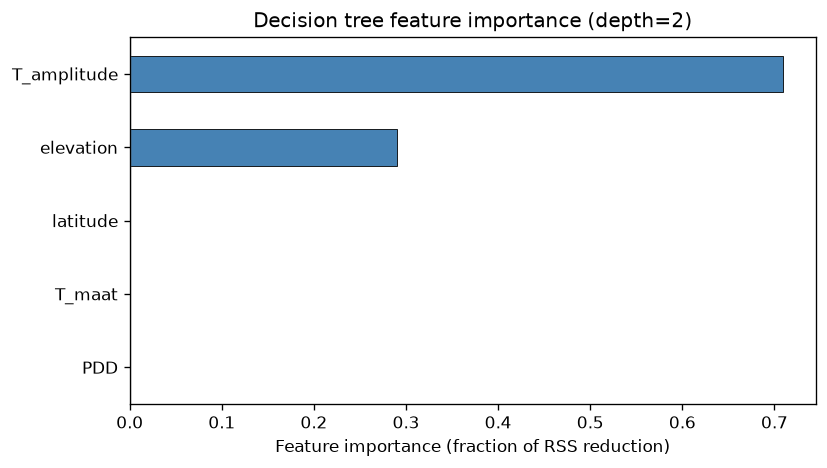

Saved: figures/fig_09b_feature_importance.pdf


In [17]:
# Feature importance bar chart
fi_sorted = fi.sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
fi_sorted.plot.barh(ax=ax, color='steelblue', edgecolor='k', linewidth=0.5)
ax.set_xlabel('Feature importance (fraction of RSS reduction)')
ax.set_title(f'Decision tree feature importance (depth={PLOT_DEPTH})')
ax.axvline(0, color='grey', lw=0.8)
plt.tight_layout()
plt.savefig('../figures/fig_09b_feature_importance.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_09b_feature_importance.pdf')

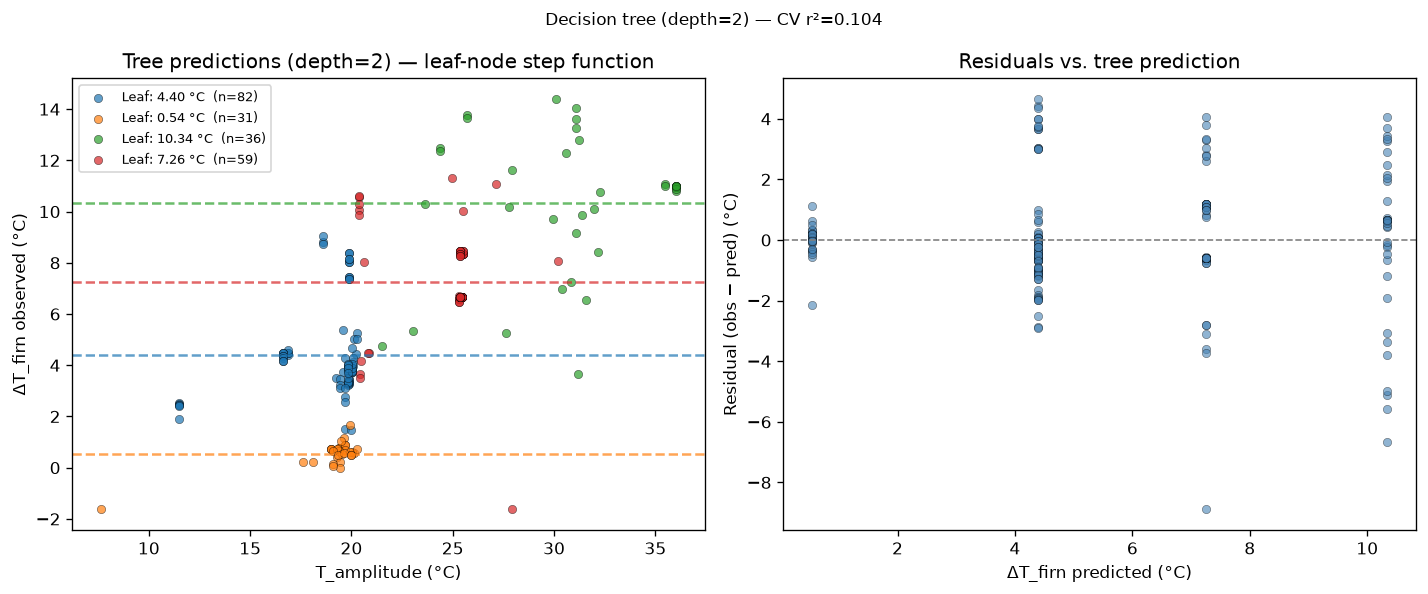

Saved: figures/fig_09c_tree_residuals.pdf


In [18]:
# Plot tree predictions vs observations, colored by leaf assignment
leaf_ids  = dt_final.apply(X)
unique_leaves = np.unique(leaf_ids)
leaf_color_map = {leaf: CLUSTER_COLORS[i % len(CLUSTER_COLORS)]
                  for i, leaf in enumerate(unique_leaves)}

y_pred = dt_final.predict(X)
residuals = y - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for leaf in unique_leaves:
    mask = leaf_ids == leaf
    pred_val = y_pred[mask][0]
    ax1.scatter(df_dt.loc[df_dt.index[mask], 'T_amplitude'],
                y[mask],
                color=leaf_color_map[leaf], alpha=0.7, edgecolors='k',
                linewidths=0.3, s=25,
                label=f'Leaf: {pred_val:.2f} °C  (n={mask.sum()})')
    ax1.axhline(pred_val, color=leaf_color_map[leaf], ls='--', lw=1.5, alpha=0.7)

ax1.set_xlabel('T_amplitude (°C)')
ax1.set_ylabel('ΔT_firn observed (°C)')
ax1.set_title(f'Tree predictions (depth={PLOT_DEPTH}) — leaf-node step function')
ax1.legend(fontsize=8)

ax2.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', linewidths=0.3, s=25, color='steelblue')
ax2.axhline(0, color='grey', lw=1, ls='--')
ax2.set_xlabel('ΔT_firn predicted (°C)')
ax2.set_ylabel('Residual (obs − pred) (°C)')
ax2.set_title('Residuals vs. tree prediction')

plt.suptitle(f'Decision tree (depth={PLOT_DEPTH}) — '
             f'CV r²={dt_cv_results[PLOT_DEPTH]:.3f}', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/fig_09c_tree_residuals.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_09c_tree_residuals.pdf')

---
## 3. KNN regression — non-parametric ceiling

KNN finds the k most similar boreholes in standardised feature space and predicts
their mean ΔT_firn. Non-parametric — no assumed functional form. Sets an upper bound
on what any method can achieve with these features and this sample size.

Not applicable to GloGEM directly (requires storing the full training set), but useful
as a diagnostic: if KNN >> linear regression, significant non-linear structure remains
unexploited; if KNN ≈ linear, the linear model is already near-optimal.

In [19]:
X_knn = StandardScaler().fit_transform(X)

print('KNN 5-fold CV r²  (features standardised):')
knn_cv_results = {}
for k in [3, 5, 7, 10, 15]:
    knn = KNeighborsRegressor(n_neighbors=k)
    cv  = cross_val_score(knn, X_knn, y, cv=5, scoring='r2')
    knn_cv_results[k] = cv.mean()
    print(f'  K={k:2d}: CV r² = {cv.mean():.3f} ± {cv.std():.3f}')

best_knn = max(knn_cv_results, key=knn_cv_results.get)
print(f'\nBest K by CV r²: {best_knn}  (CV r²={knn_cv_results[best_knn]:.3f})')

KNN 5-fold CV r²  (features standardised):
  K= 3: CV r² = -0.282 ± 1.545
  K= 5: CV r² = 0.161 ± 0.775
  K= 7: CV r² = 0.244 ± 0.648
  K=10: CV r² = 0.071 ± 0.943
  K=15: CV r² = -0.292 ± 1.484

Best K by CV r²: 7  (CV r²=0.244)


---
## 4. Summary and decision gate for GloGEM

In [20]:
lin_cv_r2  = cross_val_score(LinearRegression(), X_lin, y, cv=5, scoring='r2').mean()
dt1_cv_r2  = dt_cv_results.get(1, np.nan)
dt2_cv_r2  = dt_cv_results.get(2, np.nan)
dt3_cv_r2  = dt_cv_results.get(3, np.nan)
knn_best_r2 = knn_cv_results[best_knn]

summary = pd.DataFrame([
    {'Method':                   'Linear regression (T_amplitude)',
     'CV r²':                    f'{lin_cv_r2:.3f}',
     'GloGEM applicable':        'Yes — 1-variable lookup',
     'Implementation':           'regime CASE statement'},
    {'Method':                   f'K-means (k={best_k}) cluster medians',
     'CV r²':                    '— (unsupervised)',
     'GloGEM applicable':        'Yes — k cluster medians',
     'Implementation':           f'{best_k} median values, cluster by T_amp+T_maat'},
    {'Method':                   'Decision tree depth=1',
     'CV r²':                    f'{dt1_cv_r2:.3f}',
     'GloGEM applicable':        'Yes — 2 IF rules',
     'Implementation':           'single threshold on first-split feature'},
    {'Method':                   'Decision tree depth=2',
     'CV r²':                    f'{dt2_cv_r2:.3f}',
     'GloGEM applicable':        'Yes — 4 IF rules',
     'Implementation':           '2 features, 3 thresholds'},
    {'Method':                   'Decision tree depth=3',
     'CV r²':                    f'{dt3_cv_r2:.3f}',
     'GloGEM applicable':        'Marginal — 8 IF rules',
     'Implementation':           'probably overfitting at n≈155'},
    {'Method':                   f'KNN (k={best_knn}, non-parametric ceiling)',
     'CV r²':                    f'{knn_best_r2:.3f}',
     'GloGEM applicable':        'No — needs full training set',
     'Implementation':           'IDL cannot store lookup table at runtime'},
]).set_index('Method')

print(summary.to_string())
print()

# Decision gate
TREE_THRESHOLD = 0.50
dt_winner = max(dt_cv_results, key=lambda d: dt_cv_results[d] if d is not None else -1)
dt_winner_r2 = dt_cv_results[dt_winner]

print('=' * 60)
print('DECISION GATE')
print('=' * 60)
if dt_winner_r2 > TREE_THRESHOLD:
    print(f'Decision tree (depth={dt_winner}) CV r²={dt_winner_r2:.3f} > {TREE_THRESHOLD}')
    print('→ USE TREE RULES in GloGEM Step B')
    print(f'  Replace region-name CASE with: tree thresholds on {DT_FEATURES[0]}')
    leaf_vals = sorted(dt_final.tree_.value[
        dt_final.tree_.children_left == -1, 0, 0])
    print(f'  Leaf predictions: {[round(v,2) for v in leaf_vals]} °C')
else:
    print(f'Decision tree CV r²={dt_winner_r2:.3f} ≤ {TREE_THRESHOLD}')
    print('→ KEEP 2-REGIME MEDIANS in GloGEM Step B')
    maritime_med = profiles_filt[profiles_filt['regime']=='Temperate / Maritime']['dT_firn'].median()
    nonmar_med   = profiles_filt[profiles_filt['regime']!='Temperate / Maritime']['dT_firn'].median()
    print(f'  Maritime median: {maritime_med:.2f} °C')
    print(f'  Non-Maritime median: {nonmar_med:.2f} °C')

                                              CV r²             GloGEM applicable                            Implementation
Method                                                                                                                     
Linear regression (T_amplitude)               0.332       Yes — 1-variable lookup                     regime CASE statement
K-means (k=7) cluster medians      — (unsupervised)       Yes — k cluster medians  7 median values, cluster by T_amp+T_maat
Decision tree depth=1                         0.304              Yes — 2 IF rules   single threshold on first-split feature
Decision tree depth=2                         0.104              Yes — 4 IF rules                  2 features, 3 thresholds
Decision tree depth=3                         0.589         Marginal — 8 IF rules             probably overfitting at n≈155
KNN (k=7, non-parametric ceiling)             0.244  No — needs full training set  IDL cannot store lookup table at runtime

DECISIO